In [51]:
import numpy as np
import numpy.ma as ma
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.io import fits

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/spirals/')

from DRP_vel_map_functions import model_vel_map

In [16]:
DATA_DIR = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/DR17/'

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits'

In [13]:
master_table_dict = {}
for i in range(len(master_table)):

    master_table_dict[master_table['plateifu'][i]] = i

In [15]:
test_gal = '10001-12701'
idx = master_table_dict[test_gal]

In [48]:
### extract the vel map and coord map
plate, ifu = test_gal.split('-')
cube_fn = DATA_DIR + plate + '/' + ifu + '/manga-' + test_gal + '-MAPS-HYB10-MILESHC-MASTARSSP.fits.gz'
cube = fits.open(cube_fn)
Ha_vel = cube['EMLINE_GVEL'].data[23]
Ha_vel_MASK = cube['EMLINE_GVEL_MASK'].data[23]

skyco_x = cube['SPX_SKYCOO'].data[0]
skyco_y = cube['SPX_SKYCOO'].data[1]
cube.close()

In [97]:
Ha_vel[20,20]

-16.398596

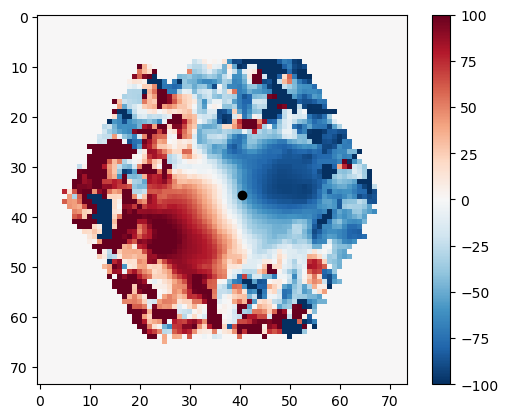

In [82]:
plt.imshow(Ha_vel, vmin=-100, vmax=100, cmap='RdBu_r')
plt.colorbar()
plt.scatter(x0,y0, color='k')

In [83]:
x0, y0

(40.498136091716646, 35.67697317107055)

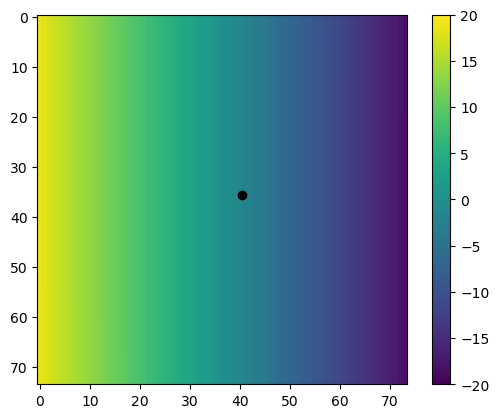

In [104]:
plt.imshow(skyco_x, vmin=-20, vmax=20)
plt.colorbar()
plt.scatter(x0,y0, color='k')


1.4994768


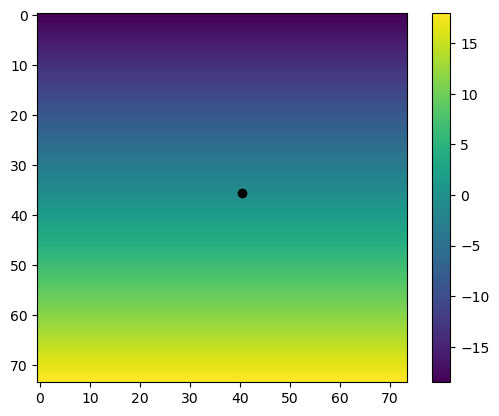

In [105]:
plt.imshow(skyco_y)
plt.colorbar()
plt.scatter(x0,y0, color='k')

print(skyco_y[int(x0), int(y0)])

In [111]:
delta_ra = skyco_x[int(x0)][int(y0)]

In [112]:
delta_dec = skyco_y[int(x0)][int(y0)]

In [113]:
objra

133.371090612

In [114]:
objdec

57.5984251446

In [115]:
kin_ra = objra + delta_ra / (3600)
kin_dec = objdec + delta_dec/ 3600

In [116]:
kin_ra

133.37136806524703

In [117]:
kin_dec

57.59884166593068

In [125]:
centers = Table.read('/Users/nityaravi/Downloads/manga_kinematic_centers.fits')
centers[0:5]

plateifu,objra,objdec,kin_center_ra,kin_center_dec
bytes32,float64,float64,float64,float64
10001-12701,133.371090612,57.5984251446,133.37136806524703,57.59884166593068
10001-12702,133.685669869,57.4802503218,133.68566993942432,57.48011111099636
10001-12703,136.017159969,57.0923291779,136.0171599858419,57.09232900000001
10001-12704,133.989966869,57.6779676669,133.9899685430747,57.677829111002396
10001-12705,136.75137451,57.4514369241,136.7513720835557,57.45129811100007
